# Image Classification of Dog Breeds — Complete Project Report
### PRINCIPLE OF ARTIFICIAL INTELLIGENCE (ISB46703) — UniKL MIIT

**Domain:** Animal Subspecies (Dog Breeds)
**Classes (5):** Bulldog, Chihuahua, German Shepherd, Golden Retriever, Siberian Husky

**Team and roles**

| Name | Student ID | Role | Phase |
|---|---|---|---|
| Muhammad Harith bin Taufik | 52215123441 | Data Engineer | Part 1 — Data Preparation |
| Fahmie Firdaus bin Abdul Razak | 52215123441 | Data Scientist | Part 2 — Data Modelling |
| Muhammad Hakiem bin Taufik | 52215123442 | Data Analyst | Part 3 — Data Visualisation & Evaluation |


---
# PART 1 — Data Engineering (Muhammad Harith)
*Data preparation: collecting, standardising, and creating the dataset. The cells below are the Data Engineer's original work, shown for documentation. They are not re-run during the presentation.*

# Data Preparation Phase
**Course:** PRINCIPLE OF ARTIFICIAL INTELLIGENCE (ISB46703)  
**Domain:** Animal Subspecies (Dog Breeds)  
**Dog Breeds:** Bulldog, Chihuahua, German Shepherd, Golden Retriever, Siberian Husky
**NAME(Role):** 1) Muhammad Harith  (Data Engineer)  
                2) Muhammad Hakiem  (Data Scientist)  
                3) Fahmie Firdaus (Data Analyst)

---

## 1. For Introduction
As the Data Engineer, my core responsibility is to handle the data preparation phase, which includes collecting data, standardizing the data, and creating the final dataset. The chosen domain for this image classification task is Animal Subspecies, specifically focusing on five dog breeds: Chihuahua, Siberian Husky, German Shepherd, Bulldog, and Golden Retriever.

## 2. Data Collection Process

To build a robust dataset, data was gathered from multiple sources to ensure high volume and variety.
**Data Sources:** 1) Automated Web Crawling (Baidu)  
                  2) Download from Pexels.com  
                  3) Download from Google Images

### 2.1 Automated Web Crawling (Baidu)
I utilized the `icrawler` library to extract images from Baidu search results. To maximize the dataset size and variety, two separate crawling scripts were executed with different search query variations.

**Phase 1: Standard Queries**
The first script targeted standard breed names to capture general images. The target was 1,300 images per class.

In [ ]:
import os
from icrawler.builtin import BaiduImageCrawler

# Search keyword : folder name
breeds = {
    "Chihuahua dog photo": "chihuahua",
    "Siberian Husky dog photo": "siberian_husky",
    "german shepherd dog photo": "german_shepherd",
    "Bulldog dog photo": "bulldog",
    "Golden Retriever dog photo": "golden_retriever"
}

base_dir = "dataset/raw_download"
limit = 1300
threads = 6

print("Starting image collection...\n")

for keyword, folder in breeds.items():
    print(f"Downloading images for: {keyword}")

    save_path = os.path.join(base_dir, folder)
    os.makedirs(save_path, exist_ok=True)

    crawler = BaiduImageCrawler(
        storage={"root_dir": save_path},
        downloader_threads=threads
    )

    try:
        crawler.crawl(
            keyword=keyword,
            max_num=limit
        )
        print(f"Finished: {folder}\n")

    except Exception as e:
        print(f"Something went wrong with {keyword}: {e}\n")

print("All done. Next step is cleaning / removing duplicates / resizing.")

**Phase 2: Portrait Queries**
The second script targeted portrait-style photos to increase the diversity of the dataset. The target remained 1,300 images per class.

In [ ]:
import os
from icrawler.builtin import BaiduImageCrawler

# Search keyword : folder name
breeds = {
    "chihuahua dog portrait": "chihuahua2",
    "siberian husky dog portrait": "siberian_husky2",
    "german shepherd dog portrait": "german_shepherd2",
    "english bulldog": "bulldog2",
    "golden retriever portrait": "golden_retriever2"
}

base_dir = "dataset/raw_download"
limit = 1300
threads = 6

print("Starting image collection...\n")

for keyword, folder in breeds.items():
    print(f"Downloading images for: {keyword}")

    save_path = os.path.join(base_dir, folder)
    os.makedirs(save_path, exist_ok=True)

    crawler = BaiduImageCrawler(
        storage={"root_dir": save_path},
        downloader_threads=threads
    )

    try:
        crawler.crawl(
            keyword=keyword,
            max_num=limit
        )
        print(f"Finished: {folder}\n")

    except Exception as e:
        print(f"Something went wrong with {keyword}: {e}\n")

print("All done. Next step is cleaning / removing duplicates / resizing.")

### 2.2 Merging and Directory Management
Since the two crawling scripts downloaded images into separate folders, for example folder (`chihuahua` and `chihuahua2`), a custom Python script was used to merge the secondary folders into the primary folders. The script automatically renamed incoming files with a sequential 6-digit padding format (e.g., `000001.jpg`) to prevent file overwriting and ensure a clean directory structure.

In [ ]:
import os
import shutil

# Define your folder paths
source_folder = '' # put the folder name to merge
destination_folder = ''
current_number = 1
moved_count = 0

for filename in os.listdir(source_folder):
    source_path = os.path.join(source_folder, filename)

    # Make sure we are only moving files
    if os.path.isfile(source_path):
        # Extract the file extension (e.g., '.jpg', '.png')
        _, extension = os.path.splitext(filename)

        # Find the next available sequential number in the destination folder
        while True:
            # Format the number with 6 leading zeros (e.g., 000001.jpg)
            new_name = f"{current_number:06d}{extension}"
            destination_path = os.path.join(destination_folder, new_name)

            # If this filename does NOT exist in the destination, we found our slot
            if not os.path.exists(destination_path):
                break

            # If it does exist, increment the number and check again
            current_number += 1

        # Move and rename the file
        shutil.move(source_path, destination_path)
        moved_count += 1
        current_number += 1

print(f"Success! Moved and sequentially renamed {moved_count} images.")

# Optional: Clean up the empty folder
if not os.listdir(source_folder):
    os.rmdir(source_folder)
    print(f"Deleted the empty {source_folder} folder.")

### 2.3 Manual Check 
Because web scrapers or crawler will capture irrelevant or duplicate data, manual intervention was required:
* **Supplementing Data:** Additional high-quality images were manually sourced from Pexels.com and Google Images to replace discarded images and boost the overall quantity.
* **Manual Pruning and Deleting:** A thorough visual scan was conducted across all 5 breed folders to manually delete corrupted files, irrelevant images (e.g., cartoons, wrong animals) and obvious duplicates.

---

## 3. Data Standardization and Dataset Creation

To prepare the raw images for the Data Scientist's Convolutional Neural Network (CNN) models, a comprehensive standardization script (`standardize_split.py`) was executed to fulfill the requirement of standardizing data and creating the dataset[cite: 1].

### 3.1 Standardization Steps Applied
Based on the processing script, the raw images underwent the following exact standardization procedures:

* **Deduplication (MD5 Hashing):** Calculates the MD5 hash of every file before processing to guarantee zero exact duplicates in the final dataset.
* **File Integrity Verification:** Uses `PIL.Image.verify()` to check for broken or corrupted files, automatically dropping unreadable files.
* **Color Profile Standardization:** Converts any image that is not in standard RGB mode to `RGB`.
* **Uniform Resizing:** Resizes every image to exactly 224x224 pixels using the `Image.Resampling.LANCZOS` filter for high-quality downsampling.
* **Format and Naming Standardization:** Saves all processed images uniformly as `JPEG` files and renames them sequentially by class.
* **Class Balancing:** Caps the maximum number of images per class at exactly 1,000 images to prevent class imbalance.

### 3.2 Dataset Splitting
Once cleaned and standardized, the dataset was divided into three distinct subsets using the `splitfolders` library with a fixed random seed (`seed=42`) for reproducibility.

| Dataset Split | Percentage | Purpose |
| :--- | :--- | :--- |
| **Training** | 70% | Used by the Data Scientist to train the neural network models. |
| **Validation** | 15% | Used during training to tune hyperparameters and monitor overfitting. |
| **Testing** | 15% | Used by the Data Analyst to evaluate the final performance and generate the confusion matrix.|

The code below executes the standardization and final splitting.

In [ ]:
import os
import hashlib
import splitfolders
from PIL import Image

# Configuration
RAW_DIR = "dataset/raw_download"
CLEAN_DIR = "dataset/cleaned_balanced"
FINAL_DIR = "dataset"   # split written here so Part 2 reads dataset/train, dataset/val, dataset/test directly
TARGET_SIZE = (224, 224)
TARGET_COUNT = 1000

def get_image_hash(filepath):
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def process_and_clean_images():
    os.makedirs(CLEAN_DIR, exist_ok=True)

    for breed_folder in os.listdir(RAW_DIR):
        breed_path = os.path.join(RAW_DIR, breed_folder)
        if not os.path.isdir(breed_path): continue

        clean_breed_path = os.path.join(CLEAN_DIR, breed_folder)
        os.makedirs(clean_breed_path, exist_ok=True)

        seen_hashes = set()
        valid_images = 0

        for filename in os.listdir(breed_path):
            if valid_images >= TARGET_COUNT: break
            filepath = os.path.join(breed_path, filename)

            try:
                # 1. Deduplication check FIRST
                img_hash = get_image_hash(filepath)
                if img_hash in seen_hashes:
                    continue

                # 2. Open and verify image
                with Image.open(filepath) as img:
                    img.verify()

                # 3. Re-open to process, convert to RGB, resize
                with Image.open(filepath) as img:
                    if img.mode != 'RGB':
                        img = img.convert('RGB')

                    img = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)

                    # 4. Save final valid image directly
                    seen_hashes.add(img_hash)
                    final_path = os.path.join(clean_breed_path, f"{breed_folder}_{valid_images:04d}.jpg")
                    img.save(final_path, "JPEG")
                    valid_images += 1

            except Exception:
                continue  # Skip unreadable/corrupted files

        print(f"Processed {valid_images} standardized images for {breed_folder}")

        if valid_images < TARGET_COUNT:
            print(f"  -> Note: {breed_folder} fell short of the {TARGET_COUNT} target.")

def split_dataset():
    print("\nSplitting dataset into 70% Train, 15% Validation, 15% Test...")
    splitfolders.ratio(
        CLEAN_DIR,
        output=FINAL_DIR,
        seed=42,
        ratio=(0.7, 0.15, 0.15),
        group_prefix=None,
        move=False
    )
    print(f"Dataset successfully built in: {FINAL_DIR}")

# Execute
print("Starting Cleaning and Standardization Phase...")
process_and_clean_images()
split_dataset()

The next part is to train the datasets that will be doing by Hakiem.

---
# PART 2 — Data Scientist (Fahmie Firdaus)
*Data modelling: building three convolutional neural networks with transfer learning, training each for 50 epochs, and recording their performance. The code below is the Data Scientist's original work; explanations have been added before each step. These cells were already executed and the trained models saved, so they are not re-run live (training takes several hours).*

### 2.1 Loading the prepared dataset

The dataset built in Part 1 is loaded straight from its folders using Keras' `image_dataset_from_directory`, which reads each breed sub-folder as a separate class. Every image is resized to **224×224** (the size all three networks expect) and images are processed in **batches of 32**. `label_mode="categorical"` gives each image a one-hot label.

The **test** set is loaded with `shuffle=False` on purpose: keeping the images in a fixed order is what lets the confusion matrix in Part 3 line up correctly. Finally, `.cache().prefetch()` keeps the data pipeline fed so training is not slowed down by disk reads.

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)   # all three models expect 224x224 images
BATCH    = 32
EPOCHS   = 50

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/train", image_size=IMG_SIZE, batch_size=BATCH, label_mode="categorical")
val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/val",   image_size=IMG_SIZE, batch_size=BATCH, label_mode="categorical")
test_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/test",  image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="categorical", shuffle=False)   # keep order for the confusion matrix

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Speed up data loading
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 3565 files belonging to 5 classes.
Found 810 files belonging to 5 classes.
Found 771 files belonging to 5 classes.
Classes: ['bulldog', 'chihuahua', 'german_shepherd', 'golden_retriever', 'siberian_husky']


### 2.2 Building a transfer-learning model

Rather than training a network from scratch (which would need millions of images), this uses **transfer learning**. The `build_model` function:

1. Downloads a CNN that was already trained on the large ImageNet dataset, **without** its original output layer (`include_top=False`).
2. **Freezes** that base (`base.trainable = False`) so its learned visual features are kept as-is.
3. Adds a small new "head": `GlobalAveragePooling2D` to summarise the features, a `Dropout(0.2)` layer to reduce overfitting, and a final `Dense` layer with one output per breed and a `softmax` activation that turns the outputs into class probabilities.

Each network also gets its **own** `preprocess_input` function, because ResNet, DenseNet and MobileNet expect their inputs scaled differently. The model is compiled with the Adam optimiser and categorical cross-entropy loss (the standard choice for multi-class classification).

In [ ]:
from tensorflow.keras import layers, Model, Input

def build_model(base_fn, preprocess_fn):
    # 1) download the pre-trained CNN WITHOUT its original top layer
    base = base_fn(include_top=False, weights="imagenet",
                   input_shape=IMG_SIZE + (3,))
    base.trainable = False          # freeze it -> transfer learning

    # 2) add our own small classifier on top
    inputs = Input(shape=IMG_SIZE + (3,))
    x = preprocess_fn(inputs)       # each model needs its own preprocessing
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model


### 2.3 Training the three networks

The same `build_model` function is reused for all three architectures — **ResNet50**, **DenseNet121**, and **MobileNetV3Large** — by looping over them. For each one the code trains for **50 epochs**, measures the **training time**, stores the **training history** (accuracy and loss at every epoch), and saves the finished model to a `.keras` file so it never has to be retrained.

Using three different-sized networks is the whole point of the project: it lets the team compare a large model (ResNet50), a medium one (DenseNet121), and a small, fast one (MobileNetV3) on the same task.

In [ ]:
import time
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV3Large
from tensorflow.keras.applications.resnet50    import preprocess_input as resnet_pre
from tensorflow.keras.applications.densenet    import preprocess_input as densenet_pre
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_pre

configs = {
    "ResNet50":     (ResNet50,        resnet_pre),
    "DenseNet121":  (DenseNet121,     densenet_pre),
    "MobileNetV3":  (MobileNetV3Large, mobilenet_pre),
}

histories, train_times, trained = {}, {}, {}

for name, (fn, pre) in configs.items():
    print("\n=== Training", name, "===")
    model = build_model(fn, pre)
    start = time.time()
    h = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
    train_times[name] = time.time() - start
    histories[name]   = h.history
    trained[name]     = model
    model.save(f"{name}.keras")            # save so you don't retrain
    print(f"{name} finished in {train_times[name]:.0f} seconds")


=== Training ResNet50 ===
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 39s 224ms/step - accuracy: 0.8022 - loss: 0.5984 - val_accuracy: 0.8914 - val_loss: 0.3836
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.8973 - loss: 0.3427 - val_accuracy: 0.8963 - val_loss: 0.3601
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.9094 - loss: 0.2917 - val_accuracy: 0.8988 - val_loss: 0.3594
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.9223 - loss: 0.2649 - val_accuracy: 0.8914 - val_loss: 0.3637
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.9316 - loss: 0.2350 - val_accuracy: 0.8975 - val_loss: 0.3649
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.9394 - loss: 0.2132 - val_accuracy: 0.8938 - val_loss: 0.3589
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.9380 - loss: 0.2035 - val_accuracy: 0.8951 - val_loss: 0.3797
Epoch 8/5

### 2.4 Evaluating each model on the test set

After training, every model predicts on the held-out **test** images — data it never saw during training, so the scores are an honest measure of real performance. Two metrics required by the brief are computed:

- **Test accuracy** — the fraction of test images classified correctly.
- **mAP (mean Average Precision)** — a stricter score that rewards confident, precise predictions, averaged across all five breeds.

The number of **parameters** (model size) and the **training time** are also recorded, so Part 3 can weigh accuracy against cost.

In [ ]:
import numpy as np
from sklearn.metrics import average_precision_score

# true labels for the test set, in order (one-hot form)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

results = {}       # we'll fill this for the comparison table
predictions = {}

for name, model in trained.items():
    y_prob = model.predict(test_ds)          # probabilities per class
    predictions[name] = y_prob
    acc = (y_prob.argmax(1) == y_true.argmax(1)).mean()
    mAP = average_precision_score(y_true, y_prob, average="macro")
    results[name] = {
        "test_accuracy": round(float(acc), 4),
        "mAP": round(float(mAP), 4),
        "params": trained[name].count_params(),
        "train_time_s": round(train_times[name], 1),
    }
    print(name, results[name])

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 294ms/step
ResNet50 {'test_accuracy': 0.9131, 'mAP': 0.9645, 'params': 23597957, 'train_time_s': 618.7}
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 672ms/step
DenseNet121 {'test_accuracy': 0.9313, 'mAP': 0.9698, 'params': 7042629, 'train_time_s': 587.0}
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 540ms/step
MobileNetV3 {'test_accuracy': 0.9157, 'mAP': 0.9657, 'params': 3001157, 'train_time_s': 192.9}


### 2.5 Saving the results for the Data Analyst

The training histories, the results table, and the class names are written to small `.json` files. Together with the three `.keras` model files, these are the complete hand-over package that the Data Analyst uses in Part 3.  

In [ ]:
import json
json.dump(histories, open('histories.json', 'w'))
json.dump(results, open('results.json', 'w'))
json.dump(class_names, open('class_names.json', 'w'))


---
# PART 3 — Data Analysis & Evaluation (Hakiem Taufik)
*Data visualisation: producing the accuracy and loss graphs, the confusion matrices, the test-set evaluation, the model comparison, and the final conclusion.*

It produces every item the rubric asks for:
1. Accuracy and loss graphs for each model
2. A confusion matrix for each model
3. Evaluation against the test set (accuracy, mAP, per-class scores)
4. A comparison of parameters, accuracy, mAP, and training time
5. A final conclusion on the best model

### 3.0 Install libraries (run once)
If you are on Anaconda/Jupyter and TensorFlow is not installed yet, run this. On Colab it finishes instantly. Use `%pip` (not plain `pip`) so it installs into this notebook's environment.

In [9]:
%pip install -q tensorflow scikit-learn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


### 3.1 Setup
Loads the libraries and points to the test images. This uses the same `dataset/` folder produced in Part 1 and read in Part 2 — one consistent path across the whole project.

In [1]:
import os, zipfile, json, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, average_precision_score)

# If you only have a zipped dataset, unzip it first
if os.path.exists("dataset.zip") and not os.path.isdir("dataset"):
    with zipfile.ZipFile("dataset.zip") as z:
        z.extractall(".")
    print("Unzipped dataset.zip")

# Test images live in dataset/test - the same dataset/ folder the Data Engineer
# produces (Part 1) and the Data Scientist trains from (Part 2).
TEST_DIR = "dataset/test"
if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(
        f"'{TEST_DIR}' not found. Put the 'dataset' folder (with train, val and test "
        f"inside it) in the same folder as this notebook.")

print("TensorFlow version:", tf.__version__)
print("Using test folder:", TEST_DIR)

TensorFlow version: 2.21.0
Using test folder: dataset/test


### 3.2 Load the hand-over files from the Data Scientist
Checks that the models and `.json` files are present.

In [2]:
IMG_SIZE = (224, 224)
BATCH = 32

class_names = json.load(open("class_names.json"))
results     = json.load(open("results.json"))
histories   = json.load(open("histories.json"))
num_classes = len(class_names)

model_files = {
    "ResNet50":    "ResNet50.keras",
    "DenseNet121": "DenseNet121.keras",
    "MobileNetV3": "MobileNetV3.keras",
}

print("Classes (%d):" % num_classes, class_names)
print()
for name, path in model_files.items():
    print(f"  {name + '.keras':<20}", "found" if os.path.exists(path) else "MISSING - please add it")

Classes (5): ['bulldog', 'chihuahua', 'german_shepherd', 'golden_retriever', 'siberian_husky']

  ResNet50.keras       found
  DenseNet121.keras    found
  MobileNetV3.keras    found


### 3.3 Accuracy and loss graphs (rubric item 1)

Each figure shows a model across its 50 training epochs. Reading **train vs validation**: if training accuracy keeps rising while validation flattens and validation **loss starts climbing**, the model is **overfitting** — an important point for the conclusion.

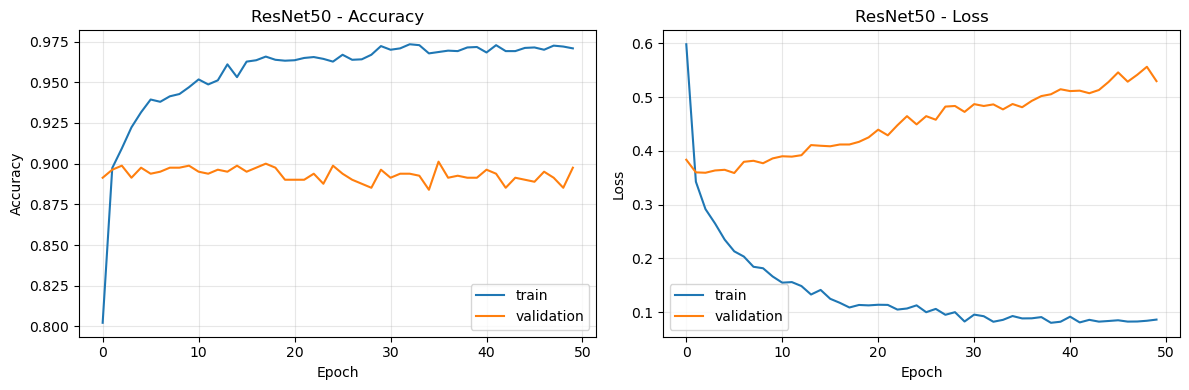

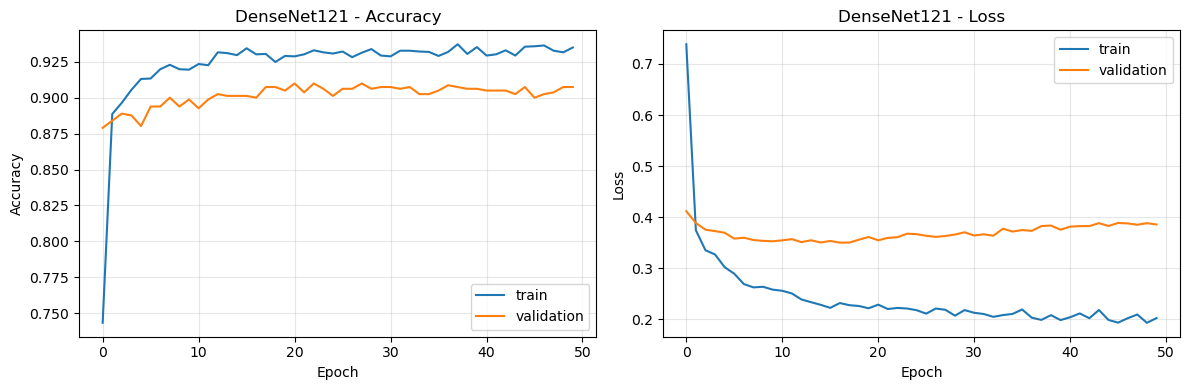

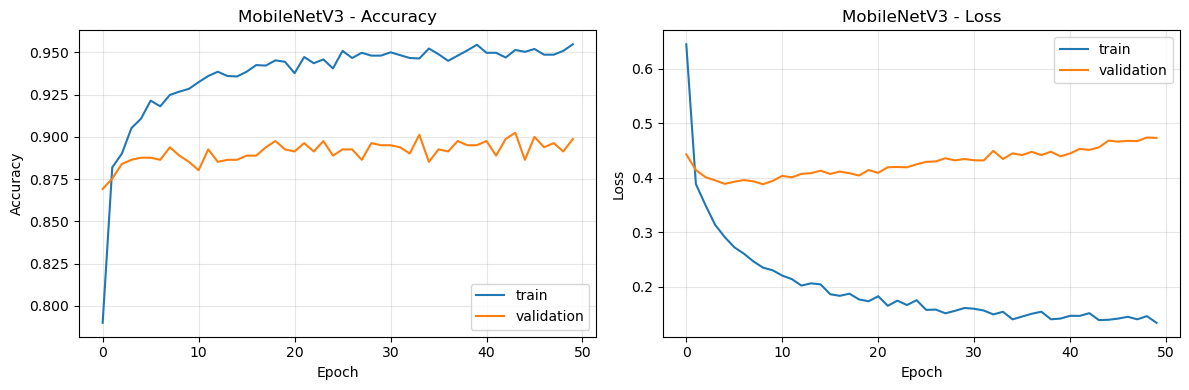

In [3]:
for name, h in histories.items():
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["accuracy"], label="train")
    ax[0].plot(h["val_accuracy"], label="validation")
    ax[0].set_title(f"{name} - Accuracy"); ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy"); ax[0].legend(); ax[0].grid(True, alpha=0.3)
    ax[1].plot(h["loss"], label="train")
    ax[1].plot(h["val_loss"], label="validation")
    ax[1].set_title(f"{name} - Loss"); ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss"); ax[1].legend(); ax[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"curves_{name}.png", dpi=120, bbox_inches="tight")
    plt.show()

**All three models on one chart** 

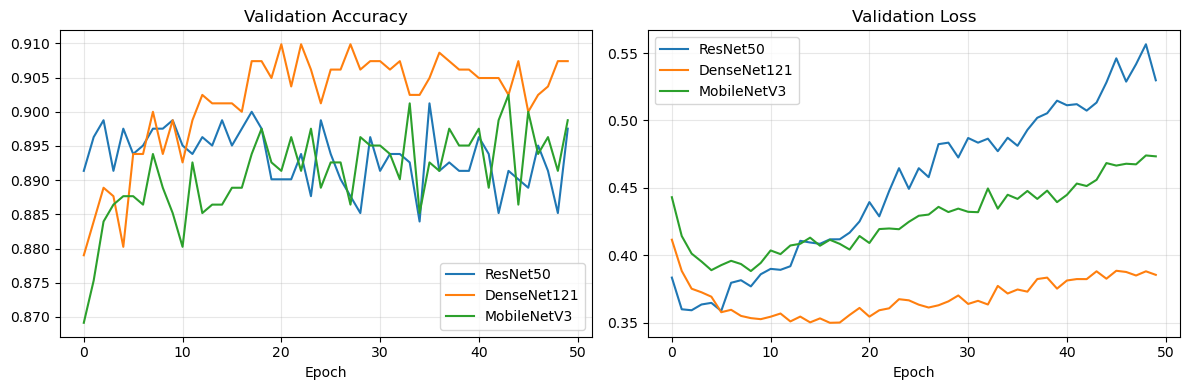

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, h in histories.items():
    ax[0].plot(h["val_accuracy"], label=name)
    ax[1].plot(h["val_loss"], label=name)
ax[0].set_title("Validation Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(True, alpha=0.3)
ax[1].set_title("Validation Loss"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("curves_comparison.png", dpi=120, bbox_inches="tight"); plt.show()

### 3.4 Load the test set and the trained models
`shuffle=False` keeps the image order fixed so the confusion matrix is correct.

In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="categorical", shuffle=False)

# safety check: the test folders must match the class order from training
assert test_ds.class_names == class_names, (
    "Class order mismatch!\n  test set: %s\n  expected: %s"
    % (test_ds.class_names, class_names))

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

models, predictions = {}, {}
for name, path in model_files.items():
    if not os.path.exists(path):
        print("Skipping", name, "- file not found"); continue
    print("Loading and predicting:", name, "...")
    models[name] = tf.keras.models.load_model(path, compile=False)
    predictions[name] = models[name].predict(test_ds, verbose=0)
print("Done. Models evaluated:", list(predictions.keys()))

Found 771 files belonging to 5 classes.
Loading and predicting: ResNet50 ...
Loading and predicting: DenseNet121 ...
Loading and predicting: MobileNetV3 ...
Done. Models evaluated: ['ResNet50', 'DenseNet121', 'MobileNetV3']


### 3.5 Confusion matrix for each model (rubric item 2)
Big numbers on the diagonal are correct. A large off-diagonal number shows two breeds the model mixes up.

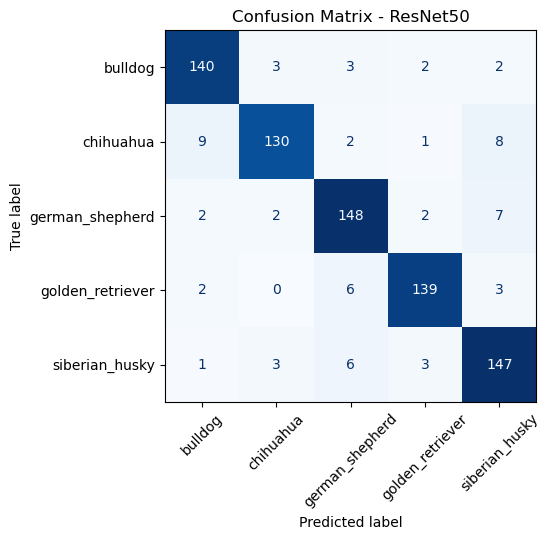

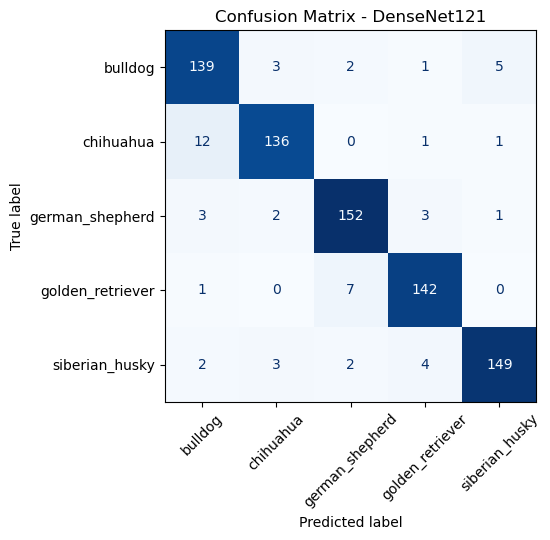

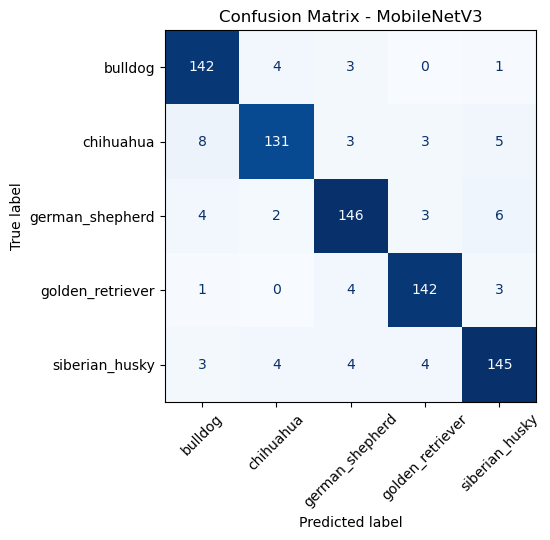

In [6]:
for name, y_prob in predictions.items():
    cm = confusion_matrix(y_true.argmax(1), y_prob.argmax(1))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title(f"Confusion Matrix - {name}")
    plt.tight_layout(); plt.savefig(f"confusion_{name}.png", dpi=120, bbox_inches="tight"); plt.show()

### 3.6 Evaluation against the test set (rubric item 3)
Recomputes accuracy and mAP (these match the saved results) and prints precision/recall/F1 for each breed.

In [7]:
for name, y_prob in predictions.items():
    acc = (y_prob.argmax(1) == y_true.argmax(1)).mean()
    mAP = average_precision_score(y_true, y_prob, average="macro")
    print("=" * 64)
    print(f"{name}   test accuracy = {acc:.4f}   mAP = {mAP:.4f}")
    print("-" * 64)
    print(classification_report(y_true.argmax(1), y_prob.argmax(1),
          target_names=class_names, zero_division=0))

ResNet50   test accuracy = 0.9131   mAP = 0.9645
----------------------------------------------------------------
                  precision    recall  f1-score   support

         bulldog       0.91      0.93      0.92       150
       chihuahua       0.94      0.87      0.90       150
 german_shepherd       0.90      0.92      0.91       161
golden_retriever       0.95      0.93      0.94       150
  siberian_husky       0.88      0.92      0.90       160

        accuracy                           0.91       771
       macro avg       0.91      0.91      0.91       771
    weighted avg       0.91      0.91      0.91       771

DenseNet121   test accuracy = 0.9313   mAP = 0.9698
----------------------------------------------------------------
                  precision    recall  f1-score   support

         bulldog       0.89      0.93      0.91       150
       chihuahua       0.94      0.91      0.93       150
 german_shepherd       0.93      0.94      0.94       161
golden_retr

### 3.7 Model comparison (rubric item 4)
Brings the four factors — accuracy, mAP, parameters, and training time — into one table and two charts.

             Test accuracy     mAP  Params (M)  Train time (s)
ResNet50            0.9131  0.9645       23.60           618.7
DenseNet121         0.9313  0.9698        7.04           587.0
MobileNetV3         0.9157  0.9657        3.00           192.9


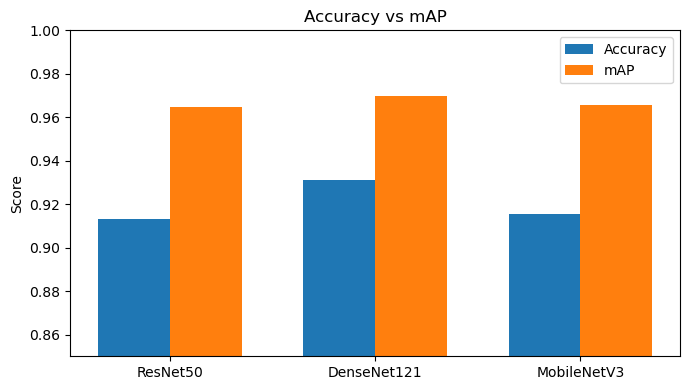

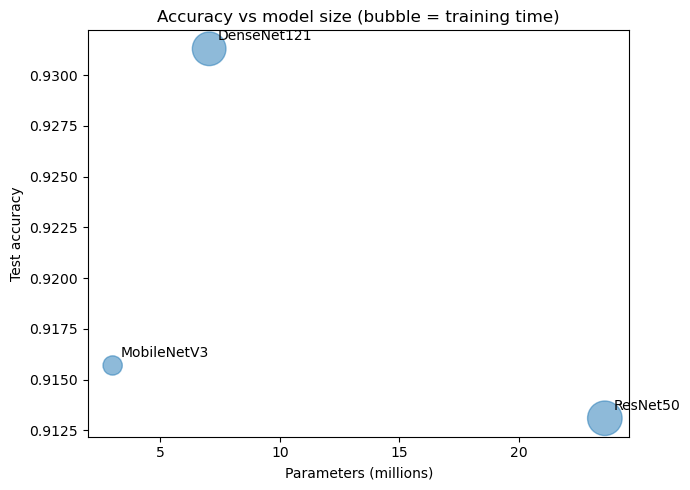

In [8]:
df = pd.DataFrame(results).T
df["params_millions"] = (df["params"] / 1e6).round(2)
df = df[["test_accuracy", "mAP", "params_millions", "train_time_s"]]
df.columns = ["Test accuracy", "mAP", "Params (M)", "Train time (s)"]
df.to_csv("model_comparison.csv")
print(df.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(df)); w = 0.35
ax.bar(x - w/2, df["Test accuracy"], w, label="Accuracy")
ax.bar(x + w/2, df["mAP"], w, label="mAP")
ax.set_xticks(x); ax.set_xticklabels(df.index)
ax.set_ylim(0.85, 1.0); ax.set_ylabel("Score"); ax.set_title("Accuracy vs mAP"); ax.legend()
plt.tight_layout(); plt.savefig("compare_accuracy_map.png", dpi=120, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["Params (M)"], df["Test accuracy"], s=df["Train time (s)"], alpha=0.5)
for n in df.index:
    ax.annotate(n, (df.loc[n, "Params (M)"], df.loc[n, "Test accuracy"]),
                textcoords="offset points", xytext=(6, 6))
ax.set_xlabel("Parameters (millions)"); ax.set_ylabel("Test accuracy")
ax.set_title("Accuracy vs model size (bubble = training time)")
plt.tight_layout(); plt.savefig("efficiency.png", dpi=120, bbox_inches="tight"); plt.show()

### 3.8 Final conclusion (rubric item 5)

**Verdict summary**

| Criterion | Best model |
|---|---|
| Test accuracy | DenseNet121 (0.9313) |
| mAP | DenseNet121 (0.9698) |
| Fewest parameters | MobileNetV3 (3.0 M) |
| Fastest training | MobileNetV3 (~193 s) |
| Least overfitting | DenseNet121 |
| **Best overall for this task** | **DenseNet121** |
| Best for a phone / limited hardware | MobileNetV3 |

**Conclusion**

Across all five dog breeds, **DenseNet121 performed best**, achieving the highest test accuracy (0.9313) and the highest mAP (0.9698) while using only about 7 million parameters. ResNet50 has more than three times as many parameters (23.6 M) yet scored the lowest accuracy (0.9131) and overfit the most as its validation loss rose during training while its training accuracy kept climbing which shows that a larger model does not automatically give better results. MobileNetV3 was the most efficient model: the smallest (3.0 M parameters) and the fastest to train (~193 seconds), with only a small drop in accuracy (0.9157).

**For this dog-breed classification task, where accuracy is the priority and there is no limit on model size, DenseNet121 is the most suitable model**, because it gives the best accuracy and mAP at a moderate size. If the model had to run on limited hardware such as a mobile phone, MobileNetV3 would be the better choice thanks to its small size and fast inference, at the cost of slightly lower accuracy.